# Homework 1: Regression & Classification - SOLUTIONS

In this homework, you will implement:
1. **Linear Regression** using the closed-form (normal equations) solution
2. **Ridge Regression** with L2 regularization
3. **LASSO Regression** with L1 regularization
4. **Kernel Ridge Regression** using the kernel trick
5. **Logistic Regression** for binary classification using gradient descent

**Requirements:**
- All implementations must be **vectorized** using NumPy (no explicit Python loops for per-sample operations).

**Key Learning Objectives**: 
- Understand *why* Ridge Regression exists by exploring numerical stability issues with ordinary least squares
- Compare Ridge (L2) vs LASSO (L1) regularization and their different properties
- Transition from regression to classification with Logistic Regression

**Canvas Submission:**
- Upload only this notebook with the solutions. Do not upload any additional files!

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import helper functions (data generation, analysis, visualization)
from regression_helpers import (
    # Data generation
    generate_warmup_data,
    generate_classification_data,
    create_collinear_data,
    create_sparse_data,
    generate_sinusoidal_data,
    # Analysis
    analyze_sensitivity,
    analyze_ridge_sensitivity,
    analyze_regularization_effect,
    compute_condition_number_analysis,
    compute_regularization_paths,
    compute_kernel_predictions,
    # Visualization
    plot_warmup_fit,
    plot_sigmoid_curve,
    plot_sigmoid_clipping_demo,
    plot_gradient_descent_loss,
    plot_decision_boundary,
    plot_weight_instability,
    plot_condition_number_analysis,
    plot_ols_vs_ridge_stability,
    plot_ridge_vs_lasso_weights,
    plot_regularization_paths,
    plot_kernel_comparison,
    plot_kernel_matrices,
)

# Import the test harness for live feedback
from regression_tests import (
    check_linear_regression,
    check_ridge_regression,
    check_lasso_regression,
    check_kernel_ridge_regression,
    check_logistic_regression,
    run_single_test,
    run_tests,
)

# Set random seed for reproducibility
np.random.seed(42)

# Matplotlib settings
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["font.size"] = 12

---
## Section 1: Introduction to Regression

### 1.1 Problem Statement

Given a dataset of $n$ samples with $p$ features:
- $\mathbf{X} \in \mathbb{R}^{n \times p}$ - design matrix (features)
- $\mathbf{y} \in \mathbb{R}^{n}$ - target values

We want to find weights $\mathbf{w} \in \mathbb{R}^{p}$ such that $\mathbf{X}\mathbf{w} \approx \mathbf{y}$.

### 1.2 Empirical Risk Minimization (ERM)

We minimize the squared error loss:

$$\mathcal{L}(\mathbf{w}) = \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 = (\mathbf{X}\mathbf{w} - \mathbf{y})^T(\mathbf{X}\mathbf{w} - \mathbf{y})$$

### 1.3 Closed-Form Solution (Normal Equations)

Taking the gradient and setting it to zero:

$$\nabla_\mathbf{w} \mathcal{L} = 2\mathbf{X}^T(\mathbf{X}\mathbf{w} - \mathbf{y}) = 0$$

$$\mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{X}^T\mathbf{y}$$

$$\mathbf{w}^* = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

This requires $\mathbf{X}^T\mathbf{X}$ to be invertible.

---
## Section 2: Warm-Up -- Fitting a Line by Hand

Before diving into matrix notation and classes, let's build intuition with the simplest possible regression problem.

**Setup**: We have $n$ data points $(x_i, y_i)$ and want to find a scalar slope $w$ such that $y \approx w \cdot x$ (no intercept).

**Derivation**: Minimize the squared error:

$$\mathcal{L}(w) = \sum_{i=1}^{n} (y_i - w \cdot x_i)^2$$

Take the derivative and set it to zero:

$$\frac{d\mathcal{L}}{dw} = -2 \sum_{i=1}^{n} x_i(y_i - w \cdot x_i) = 0$$

$$w^* = \frac{\sum_{i=1}^{n} x_i y_i}{\sum_{i=1}^{n} x_i^2}$$

This is the simplest form of linear regression -- just a ratio of two sums!

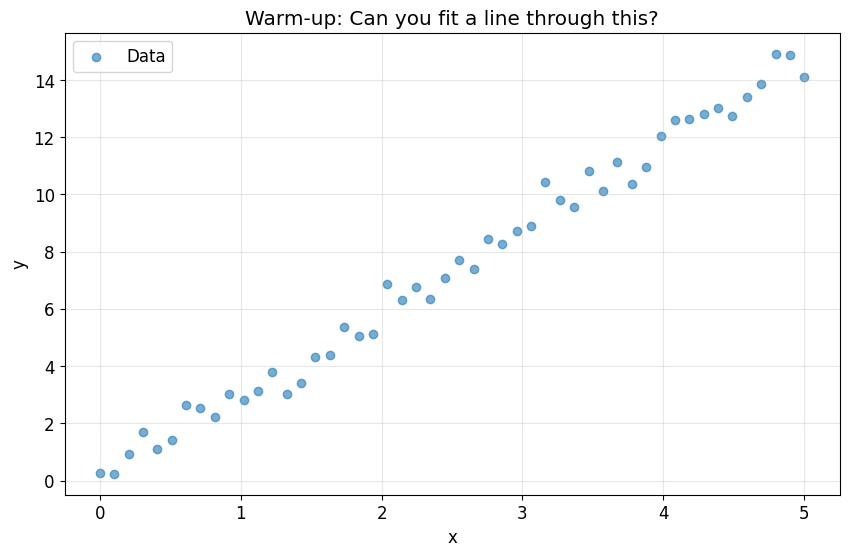

We have 50 data points.
Your task: find the slope w that best fits y = w * x


In [2]:
# Generate simple 1D data: y = 3*x + noise
X_warmup, y_warmup, true_slope = generate_warmup_data()

plt.scatter(X_warmup, y_warmup, alpha=0.6, label="Data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Warm-up: Can you fit a line through this?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"We have {len(X_warmup)} data points.")
print("Your task: find the slope w that best fits y = w * x")

In [3]:
# SOLUTION
slope = np.sum(X_warmup * y_warmup) / np.sum(X_warmup**2)

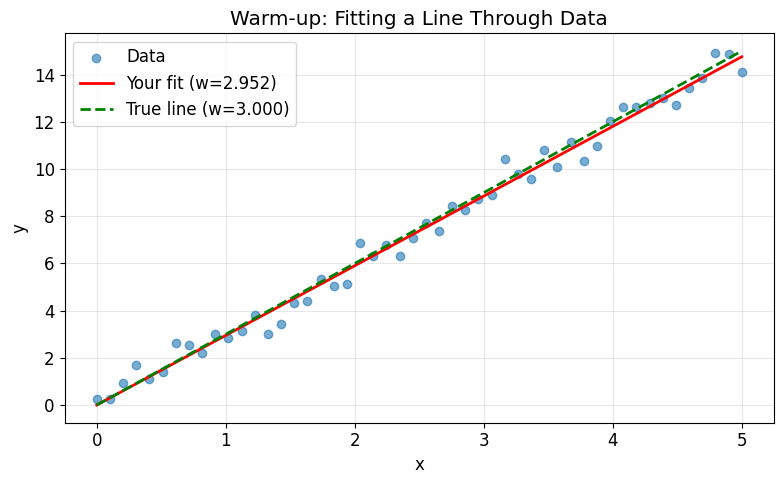

Your slope:  2.9516
True slope:  3.0000
Error:       0.0484


In [4]:
# Visualize your fit
plot_warmup_fit(X_warmup, y_warmup, slope, true_slope)
print(f"Your slope:  {slope:.4f}")
print(f"True slope:  {true_slope:.4f}")
print(f"Error:       {abs(slope - true_slope):.4f}")

---
## Section 3: Linear Regression Implementation

### Exercise 3.1: Implement the LinearRegression class

Complete the `fit` and `predict` methods below.

In [5]:
class LinearRegression:
    """
    Ordinary Least Squares Linear Regression.

    Closed-form solution: w = (X^T X)^{-1} X^T y
    """

    def __init__(self):
        self.weights = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        """
        Fit the linear regression model.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Training data
        y : np.ndarray of shape (n_samples,)
            Target values

        Returns
        -------
        self : LinearRegression
            Fitted model
        """
        y = np.asarray(y).ravel()

        # SOLUTION
        self.weights = np.linalg.inv(X.T @ X) @ X.T @ y

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict using the linear model.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Samples to predict

        Returns
        -------
        y_pred : np.ndarray of shape (n_samples,)
            Predicted values
        """
        # SOLUTION
        return X @ self.weights

### Run tests for LinearRegression

Run this cell after implementing your `LinearRegression` class to check your implementation:

Testing LinearRegression...


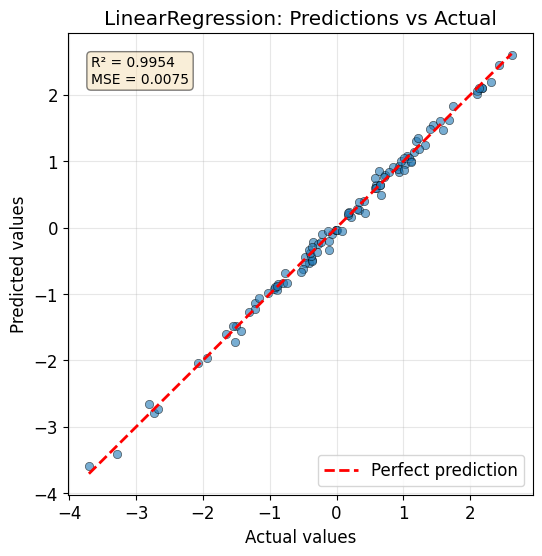

  ✓ fit_returns_self
  ✓ weights_shape
  ✓ predict_shape
  ✓ correctness
  ✓ perfect_fit

LinearRegression: 5/5 tests passed
🎉 All tests passed!


{'passed': 5,
 'failed': 0,
 'results': [('fit_returns_self', True, 'fit() should return self'),
  ('weights_shape', True, 'Expected shape (3,), got (3,)'),
  ('predict_shape', True, 'Expected shape (100,), got (100,)'),
  ('correctness', True, 'Weights should be close to true weights'),
  ('perfect_fit', True, 'Should fit perfectly when y = Xw exactly')]}

In [6]:
# Test your LinearRegression implementation
run_single_test(LinearRegression, check_linear_regression)

---
## Section 4: Why Ridge Regression Exists - Numerical Instability

This is the **most important section** of the homework. We will demonstrate why ordinary least squares (OLS) can fail catastrophically and why Ridge regression is necessary.

### 4.1 Understanding Condition Numbers

The **condition number** of a matrix $\mathbf{A}$ measures how sensitive the solution of $\mathbf{A}\mathbf{x} = \mathbf{b}$ is to perturbations:

$$\kappa(\mathbf{A}) = \|\mathbf{A}\| \cdot \|\mathbf{A}^{-1}\| = \frac{\sigma_{\max}}{\sigma_{\min}}$$

where $\sigma_{\max}$ and $\sigma_{\min}$ are the largest and smallest singular values.

**Key insight**: If $\kappa(\mathbf{A})$ is large, small changes in $\mathbf{b}$ cause large changes in $\mathbf{x}$.

For linear regression, we need to solve $(\mathbf{X}^T\mathbf{X})\mathbf{w} = \mathbf{X}^T\mathbf{y}$. If features are highly correlated (multicollinearity), $\mathbf{X}^T\mathbf{X}$ becomes **ill-conditioned** (high condition number).

### 4.2 Creating Ill-Conditioned Data

Let's create data where two features are nearly identical (highly correlated):

In [7]:
# Create ill-conditioned data using the helper function
X_bad, y_bad, true_w = create_collinear_data(collinearity=1e-10)

print(f"Correlation between x1 and x2: {np.corrcoef(X_bad[:, 0], X_bad[:, 1])[0, 1]:.10f}")
print(f"Condition number of X^T X: {np.linalg.cond(X_bad.T @ X_bad):.2e}")

Correlation between x1 and x2: 1.0000000000
Condition number of X^T X: 7.84e+16


### 4.3 Demonstrating the Failure of OLS

Let's see what happens when we try to fit OLS on ill-conditioned data:

In [8]:
# Try to fit OLS on ill-conditioned data
model_bad = LinearRegression()
model_bad.fit(X_bad, y_bad)

print("True weights:      ", true_w)
print("Estimated weights: ", model_bad.weights)
print(f"Weight error:       {np.linalg.norm(model_bad.weights - true_w):.2e}")
print()
print("Notice how the estimated weights are WILDLY different from the true weights!")
print("The individual weights may be huge with opposite signs, even though")
print("the true weights are small positive numbers.")

True weights:       [1. 2. 3.]
Estimated weights:  [ 2325.13226278 -2325.44329172     3.00340208]
Weight error:       3.29e+03

Notice how the estimated weights are WILDLY different from the true weights!
The individual weights may be huge with opposite signs, even though
the true weights are small positive numbers.


### 4.4 Sensitivity Analysis: Tiny Perturbations Cause Huge Changes

The hallmark of numerical instability is that tiny changes in input cause massive changes in output. Let's demonstrate this:

In [9]:
# Analyze sensitivity on ill-conditioned data
weights_trials = analyze_sensitivity(X_bad, y_bad, perturbation_scale=1e-10)

print("OLS weight estimates across 50 tiny perturbations (scale=1e-10):")
print(f"  Mean:   {weights_trials.mean(axis=0)}")
print(f"  Std:    {weights_trials.std(axis=0)}")
print(f"  Min:    {weights_trials.min(axis=0)}")
print(f"  Max:    {weights_trials.max(axis=0)}")
print()
print(f"True weights: {true_w}")
print()
print("OBSERVE: The standard deviation is HUGE! Tiny 1e-10 perturbations")
print("in y cause the weights to vary by enormous amounts.")

OLS weight estimates across 50 tiny perturbations (scale=1e-10):
  Mean:   [ 2328.87224787 -2325.8906819      3.00340208]
  Std:    [5.30452125e+00 5.30452125e+00 9.77406306e-12]
  Min:    [ 2313.27779002 -2341.04834889     3.00340208]
  Max:    [ 2344.02991486 -2310.29622405     3.00340208]

True weights: [1. 2. 3.]

OBSERVE: The standard deviation is HUGE! Tiny 1e-10 perturbations
in y cause the weights to vary by enormous amounts.


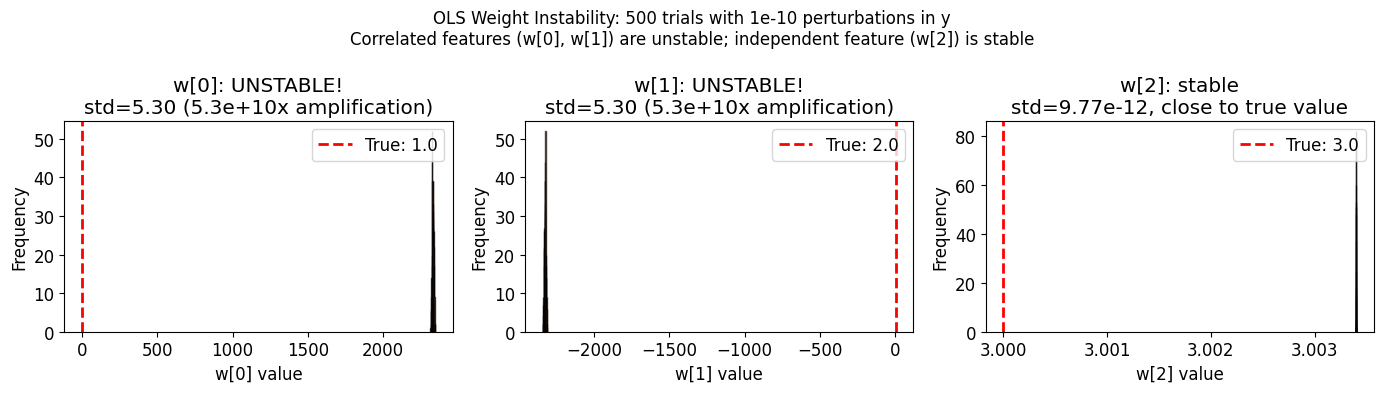

In [10]:
# Visualize the instability
plot_weight_instability(weights_trials, true_w)

### 4.5 Visualizing Condition Number vs. Stability

Let's see how the condition number affects solution stability:

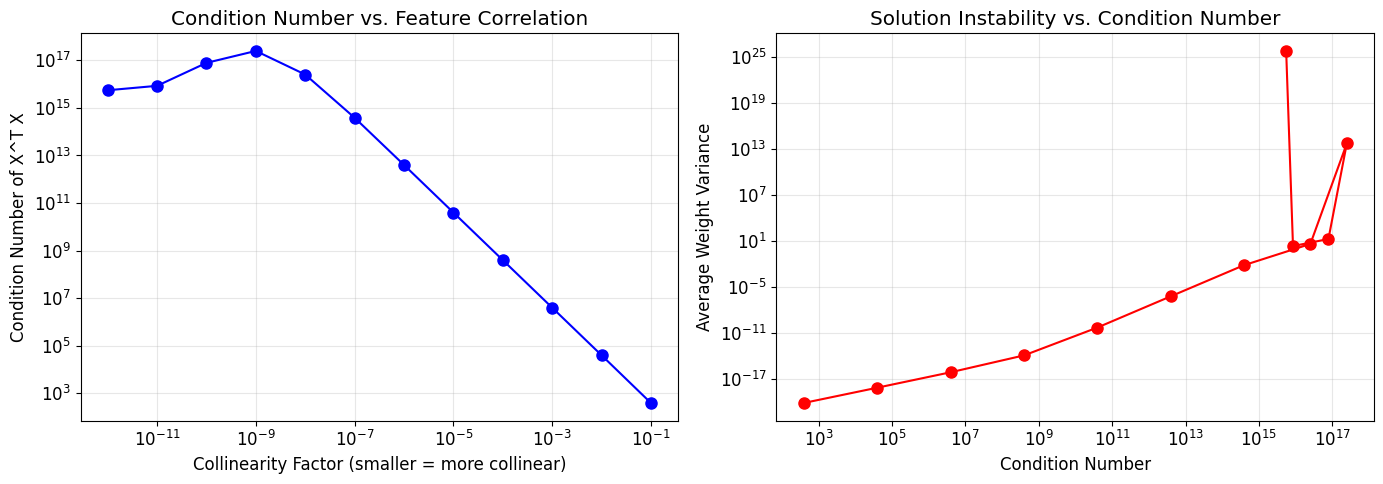

KEY INSIGHT: As condition number increases, weight variance explodes!
This is numerical instability - the OLS solution becomes meaningless.
NOTE: The right plot may appear to 'go back' because at extreme condition numbers (~10^17),
      numerical precision breaks down and even computing the condition number becomes unreliable.


In [11]:
# Compute and visualize condition number vs stability
collinearity_levels = np.logspace(-1, -12, 12)
condition_numbers, weight_variances = compute_condition_number_analysis(collinearity_levels)
plot_condition_number_analysis(collinearity_levels, condition_numbers, weight_variances)

---
## Section 5: Ridge Regression - The Solution

### 5.1 The Ridge Regression Idea

Ridge regression adds L2 regularization to the loss function:

$$\mathcal{L}_{\text{ridge}}(\mathbf{w}) = \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \alpha \|\mathbf{w}\|_2^2$$

The closed-form solution becomes:

$$\mathbf{w}^* = (\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$$

### 5.2 Why This Fixes Numerical Stability

Adding $\alpha \mathbf{I}$ to $\mathbf{X}^T\mathbf{X}$ shifts all eigenvalues by $\alpha$:

- If $\lambda_i$ is an eigenvalue of $\mathbf{X}^T\mathbf{X}$, then $\lambda_i + \alpha$ is an eigenvalue of $\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I}$
- The new condition number: $\kappa_{\text{new}} = \frac{\sigma_{\max}^2 + \alpha}{\sigma_{\min}^2 + \alpha}$
- When $\alpha \gg \sigma_{\min}^2$, the condition number is dramatically reduced!

In [12]:
# Demonstrate the effect of regularization on condition number
alphas = [1e-6, 1e-4, 1e-2, 1e0, 1e2]
new_conds = analyze_regularization_effect(X_bad, alphas)

Original condition number: 7.84e+16

       Alpha      New Cond #     Improvement
---------------------------------------------
       1e-06        1.76e+08        4.45e+08x
       1e-04        1.76e+06        4.45e+10x
       1e-02        1.76e+04        4.45e+12x
       1e+00        1.77e+02        4.42e+14x
       1e+02        2.76e+00        2.84e+16x


### Exercise 5.1: Implement the RidgeRegression class

In [13]:
class RidgeRegression:
    """
    Ridge Regression (L2 regularization).

    Closed-form solution: w = (X^T X + alpha * I)^{-1} X^T y

    Parameters
    ----------
    alpha : float, default=1.0
        Regularization strength. Must be non-negative.
    """

    def __init__(self, alpha: float = 1.0):
        self.alpha = alpha
        self.weights = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> "RidgeRegression":
        """
        Fit the ridge regression model.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Training data
        y : np.ndarray of shape (n_samples,)
            Target values

        Returns
        -------
        self : RidgeRegression
            Fitted model
        """
        y = np.asarray(y).ravel()
        n_features = X.shape[1]

        # SOLUTION: Regularized normal equations
        A = X.T @ X + self.alpha * np.eye(n_features)
        b = X.T @ y
        self.weights = np.linalg.inv(A) @ b

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict using the ridge regression model.
        """
        # SOLUTION
        return X @ self.weights

### Run tests for RidgeRegression

Run this cell after implementing your `RidgeRegression` class:

Testing RidgeRegression...


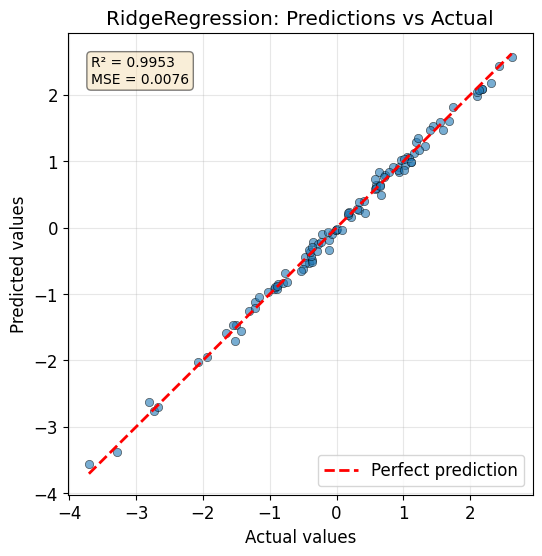

  ✓ fit_returns_self
  ✓ weights_shape
  ✓ shrinks_weights
  ✓ numerical_stability
  ✓ condition_improvement

RidgeRegression: 5/5 tests passed
🎉 All tests passed!


{'passed': 5,
 'failed': 0,
 'results': [('fit_returns_self', True, 'fit() should return self'),
  ('weights_shape', True, 'Expected shape (3,), got (3,)'),
  ('shrinks_weights', np.True_, 'Higher alpha should shrink weights more'),
  ('numerical_stability',
   np.True_,
   'Ridge should handle ill-conditioned data'),
  ('condition_improvement',
   np.True_,
   'Regularization should improve condition number')]}

In [14]:
# Test your RidgeRegression implementation
run_single_test(RidgeRegression, check_ridge_regression)

### 5.3 Compare OLS vs Ridge on Ill-Conditioned Data

In [15]:
# Compare OLS and Ridge on ill-conditioned data
print("Comparison on ILL-CONDITIONED data:")
print(f"Condition number of X^T X: {np.linalg.cond(X_bad.T @ X_bad):.2e}")
print(f"True weights: {true_w}")
print()

# OLS
ols = LinearRegression().fit(X_bad, y_bad)
ols_error = np.linalg.norm(ols.weights - true_w)
print(f"OLS weights:   {ols.weights}")
print(f"OLS error:     {ols_error:.4e}")
print()

# Ridge with different alphas
alphas = [1e-4, 1e-2, 1e0, 1e2]
print(f"{'Alpha':>10} {'Weights':>40} {'Error':>12}")
print("-" * 65)

ridge_errors = []
for alpha in alphas:
    ridge = RidgeRegression(alpha=alpha).fit(X_bad, y_bad)
    error = np.linalg.norm(ridge.weights - true_w)
    ridge_errors.append(error)
    weights_str = np.array2string(ridge.weights, precision=2, suppress_small=True)
    print(f"{alpha:>10.0e} {weights_str:>40} {error:>12.4e}")

Comparison on ILL-CONDITIONED data:
Condition number of X^T X: 7.84e+16
True weights: [1. 2. 3.]

OLS weights:   [ 2325.13226278 -2325.44329172     3.00340208]
OLS error:     3.2892e+03

     Alpha                                  Weights        Error
-----------------------------------------------------------------
     1e-04                         [1.49 1.49 3.  ]   7.0724e-01
     1e-02                         [1.49 1.49 3.  ]   7.0724e-01
     1e+00                         [1.48 1.48 2.98]   7.0774e-01
     1e+02                         [1.02 1.02 1.7 ]   1.6325e+00


### 5.4 Ridge Stability Under Perturbations

In [16]:
# Compare OLS vs Ridge stability
ols_weights = analyze_sensitivity(X_bad, y_bad, perturbation_scale=1e-10)
ridge_weights = analyze_ridge_sensitivity(X_bad, y_bad, alpha=1.0, perturbation_scale=1e-10)

print("Weight standard deviation across 50 perturbations (scale=1e-10):")
print()
print(f"OLS:   {ols_weights.std(axis=0)}")
print(f"Ridge: {ridge_weights.std(axis=0)}")
print()
print(f"Stability improvement: {ols_weights.std(axis=0).mean() / ridge_weights.std(axis=0).mean():.2e}x")

Weight standard deviation across 50 perturbations (scale=1e-10):

OLS:   [5.30452125e+00 5.30452125e+00 9.77406306e-12]
Ridge: [5.89242225e-12 5.89715214e-12 8.95819299e-12]

Stability improvement: 5.11e+11x


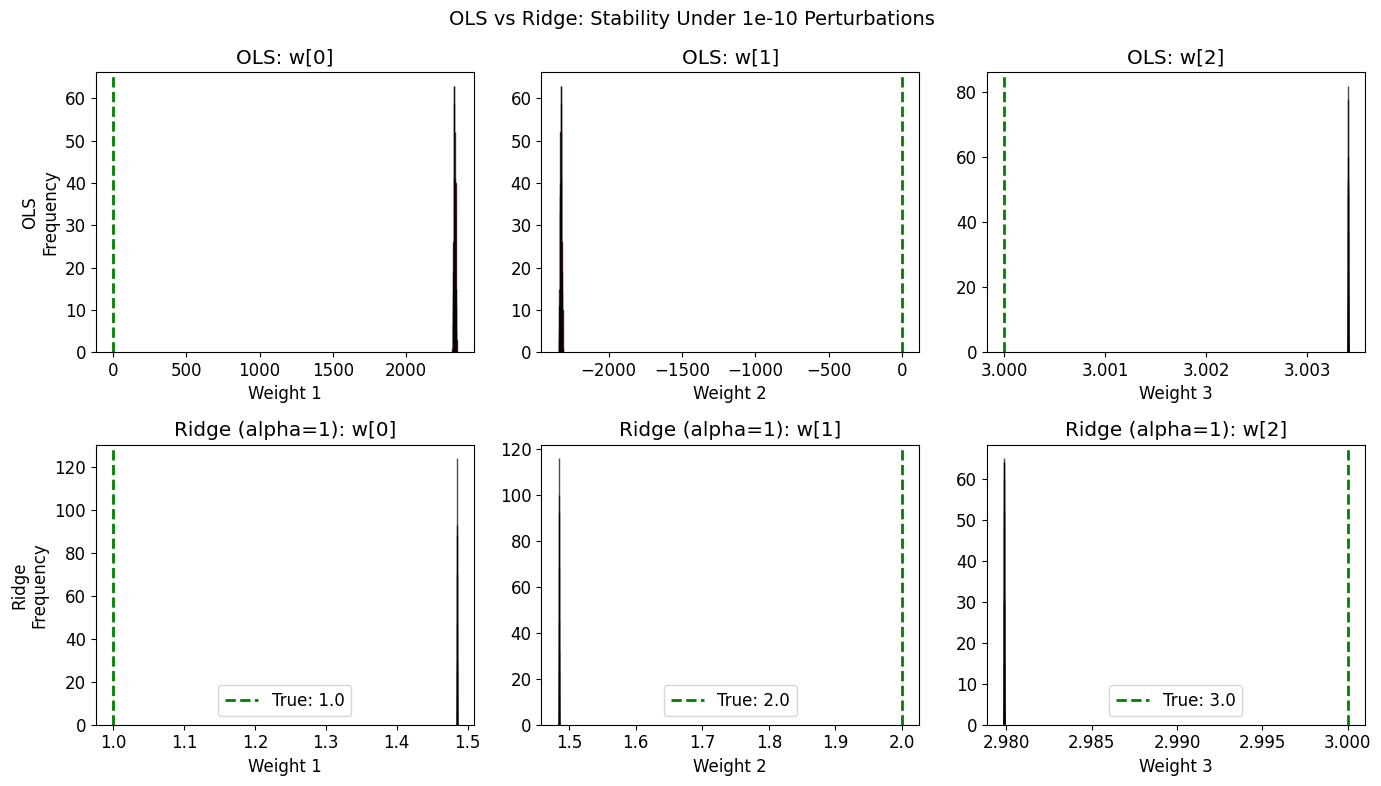

Notice how Ridge weights cluster tightly around the true values,
while OLS weights are scattered across a huge range!


In [17]:
# Visualize the stability comparison
plot_ols_vs_ridge_stability(ols_weights, ridge_weights, true_w)

---
## Section 6: LASSO Regression - L1 Regularization

### 6.1 The LASSO Idea

LASSO (Least Absolute Shrinkage and Selection Operator) uses L1 regularization:

$$\mathcal{L}_{\text{LASSO}}(\mathbf{w}) = \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \alpha \|\mathbf{w}\|_1$$

where $\|\mathbf{w}\|_1 = \sum_j |w_j|$ is the L1 norm.

### 6.2 Key Difference from Ridge

**Ridge (L2)**: Shrinks weights towards zero but never exactly to zero
- All features remain in the model with small weights

**LASSO (L1)**: Can shrink weights exactly to zero (sparse solutions)
- Performs automatic **feature selection**
- Some weights become exactly zero, effectively removing features

### 6.3 Why No Closed-Form Solution?

The L1 penalty $|w|$ is **not differentiable** at $w = 0$. We must use iterative optimization methods like:
- Coordinate Descent
- Proximal Gradient Descent
- LARS (Least Angle Regression)

We'll use **Coordinate Descent** with the **soft-thresholding operator**:

$$S(x, \lambda) = \text{sign}(x) \cdot \max(|x| - \lambda, 0)$$

### Exercise 6.1: Implement the LassoRegression class

In [ ]:
class LassoRegression:
    """
    LASSO Regression (L1 regularization).

    Minimizes: (1/2n) * ||Xw - y||^2 + alpha * ||w||_1

    Uses coordinate descent optimization with soft-thresholding.

    Parameters
    ----------
    alpha : float, default=1.0
        Regularization strength. Must be non-negative.
    max_iter : int, default=1000
        Maximum number of iterations for coordinate descent.
    tol : float, default=1e-4
        Tolerance for convergence.
    """

    def __init__(self, alpha: float = 1.0, max_iter: int = 1000, tol: float = 1e-4):
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.n_iter_ = 0

    def _soft_threshold(self, x: float, threshold: float) -> float:
        """
        Soft thresholding operator (proximal operator for L1 norm).

        S(x, t) = sign(x) * max(|x| - t, 0)

        This is the key operation that produces sparsity!
        """
        if x > threshold:
            return x - threshold
        elif x < -threshold:
            return x + threshold
        else:
            return 0.0

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LassoRegression":
        """
        Fit the LASSO regression model using coordinate descent.

        Coordinate descent updates one weight at a time while keeping others fixed.
        For each weight w_j:
        1. Compute residual r = y - X @ w + X_j * w_j (remove contribution of feature j)
        2. Compute optimal update: rho_j = X_j^T @ r
        3. Apply soft thresholding: w_j = S(rho_j, n * alpha) / ||X_j||^2

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Training data
        y : np.ndarray of shape (n_samples,)
            Target values

        Returns
        -------
        self : LassoRegression
            Fitted model
        """
        y = np.asarray(y).ravel()
        n_samples, n_features = X.shape

        # Initialize weights to zeros
        self.weights = np.zeros(n_features)

        # Precompute ||X_j||^2 for each feature
        X_col_norms_sq = np.sum(X**2, axis=0)

        # SOLUTION: Coordinate descent
        for iteration in range(self.max_iter):
            weights_old = self.weights.copy()

            # Coordinate descent: update each weight one at a time
            for j in range(n_features):
                # Compute residual without contribution from feature j
                residual = y - X @ self.weights + X[:, j] * self.weights[j]

                # Compute the optimal update (OLS solution for feature j)
                rho_j = X[:, j] @ residual

                # Apply soft thresholding
                if X_col_norms_sq[j] > 0:
                    self.weights[j] = self._soft_threshold(rho_j, n_samples * self.alpha) / X_col_norms_sq[j]
                else:
                    self.weights[j] = 0.0

            # Check convergence
            weight_change = np.linalg.norm(self.weights - weights_old)
            if weight_change < self.tol:
                break

        self.n_iter_ = iteration + 1

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict using the LASSO regression model.
        """
        # SOLUTION
        return X @ self.weights

### Run tests for LassoRegression

Run this cell after implementing your `LassoRegression` class:

Testing LassoRegression...


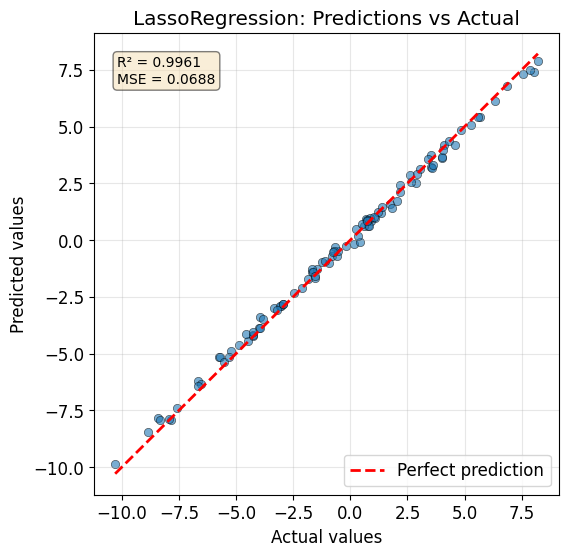

  ✓ fit_returns_self
  ✓ weights_shape
  ✓ sparsity
  ✓ more_sparsity
  ✓ feature_selection

LassoRegression: 5/5 tests passed
🎉 All tests passed!


{'passed': 5,
 'failed': 0,
 'results': [('fit_returns_self', True, 'fit() should return self'),
  ('weights_shape', True, 'Expected shape (3,), got (3,)'),
  ('sparsity', np.True_, 'LASSO should produce sparse weights, got 15 zeros'),
  ('more_sparsity', np.True_, 'Higher alpha should produce more zeros'),
  ('feature_selection', np.True_, 'Should identify informative features')]}

In [19]:
# Test your LassoRegression implementation
run_single_test(LassoRegression, check_lasso_regression)

### 6.4 Ridge vs LASSO: Visual Comparison

Let's create data with sparse true weights and compare how Ridge and LASSO behave:

In [20]:
# Create sparse data: only 5 out of 20 features are truly informative
X_sparse, y_sparse, true_weights_sparse = create_sparse_data()

print(f"True weights (first 5 are non-zero):")
print(f"  {true_weights_sparse}")
print(f"\nNumber of truly non-zero weights: {np.sum(true_weights_sparse != 0)}")

True weights (first 5 are non-zero):
  [-1.35035655 -0.28903734 -1.58483984 -0.61592306 -3.78722933  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]

Number of truly non-zero weights: 5


In [21]:
# Compare Ridge vs LASSO on sparse data
ridge_sparse = RidgeRegression(alpha=0.5).fit(X_sparse, y_sparse)
lasso_sparse = LassoRegression(alpha=0.1).fit(X_sparse, y_sparse)

print("Comparison on SPARSE data (only 5 of 20 features are informative):\n")
print(f"{'':>8} {'True':>10} {'Ridge':>10} {'LASSO':>10}")
print("-" * 42)

for i in range(len(true_weights_sparse)):
    marker = "*" if true_weights_sparse[i] != 0 else " "
    print(
        f"w[{i:2d}]{marker}  {true_weights_sparse[i]:>10.3f} {ridge_sparse.weights[i]:>10.3f} {lasso_sparse.weights[i]:>10.3f}"
    )

print("\n* = truly informative feature")
print(f"\nRidge non-zero weights: {np.sum(np.abs(ridge_sparse.weights) > 1e-6)}")
print(f"LASSO non-zero weights: {np.sum(np.abs(lasso_sparse.weights) > 1e-6)}")
print(f"True non-zero weights:  {np.sum(np.abs(true_weights_sparse) > 1e-6)}")

Comparison on SPARSE data (only 5 of 20 features are informative):

               True      Ridge      LASSO
------------------------------------------
w[ 0]*      -1.350     -1.323     -1.186
w[ 1]*      -0.289     -0.278     -0.149
w[ 2]*      -1.585     -1.572     -1.512
w[ 3]*      -0.616     -0.592     -0.462
w[ 4]*      -3.787     -3.770     -3.671
w[ 5]        0.000      0.008      0.000
w[ 6]        0.000     -0.002      0.000
w[ 7]        0.000     -0.029      0.000
w[ 8]        0.000     -0.016      0.000
w[ 9]        0.000     -0.002      0.000
w[10]        0.000      0.021      0.000
w[11]        0.000     -0.001      0.000
w[12]        0.000     -0.001      0.000
w[13]        0.000     -0.008      0.000
w[14]        0.000     -0.004      0.000
w[15]        0.000     -0.016      0.000
w[16]        0.000     -0.002      0.000
w[17]        0.000     -0.002      0.000
w[18]        0.000     -0.002      0.000
w[19]        0.000     -0.005      0.000

* = truly informative feat

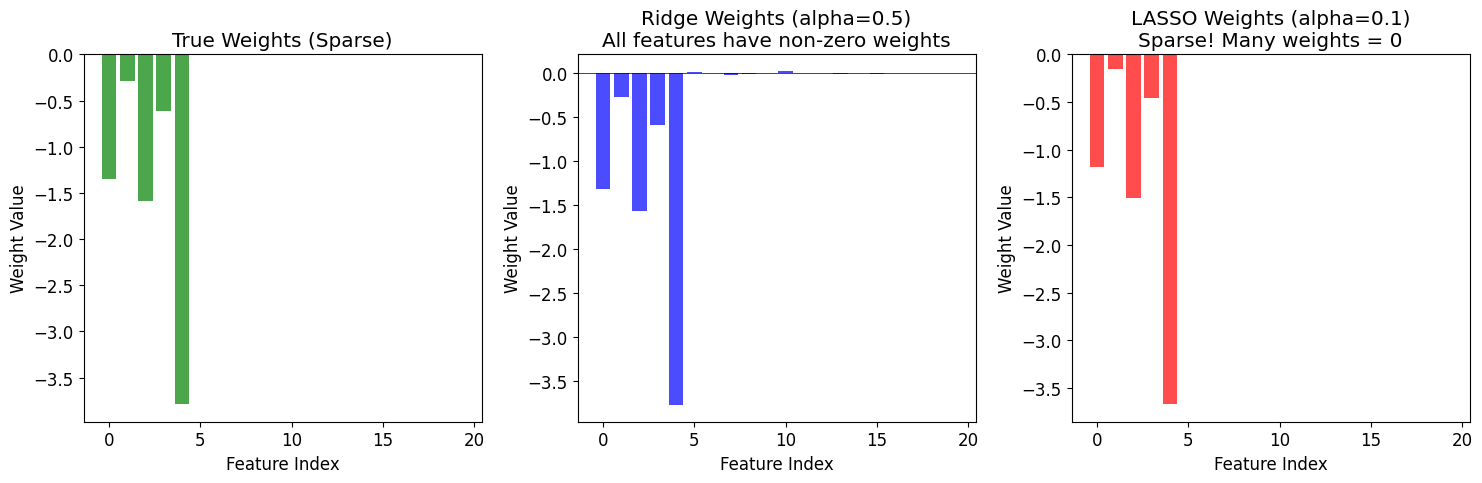


KEY OBSERVATION:
- Ridge shrinks ALL weights but keeps them non-zero
- LASSO sets many weights EXACTLY to zero (feature selection!)
- LASSO correctly identifies that only the first 5 features matter


In [22]:
# Visualize the weight comparison
plot_ridge_vs_lasso_weights(
    true_weights_sparse,
    ridge_sparse.weights,
    lasso_sparse.weights,
    ridge_sparse.alpha,
    lasso_sparse.alpha,
)

### 6.5 Regularization Path: How Weights Change with Alpha

Let's see how weights evolve as we increase regularization strength:

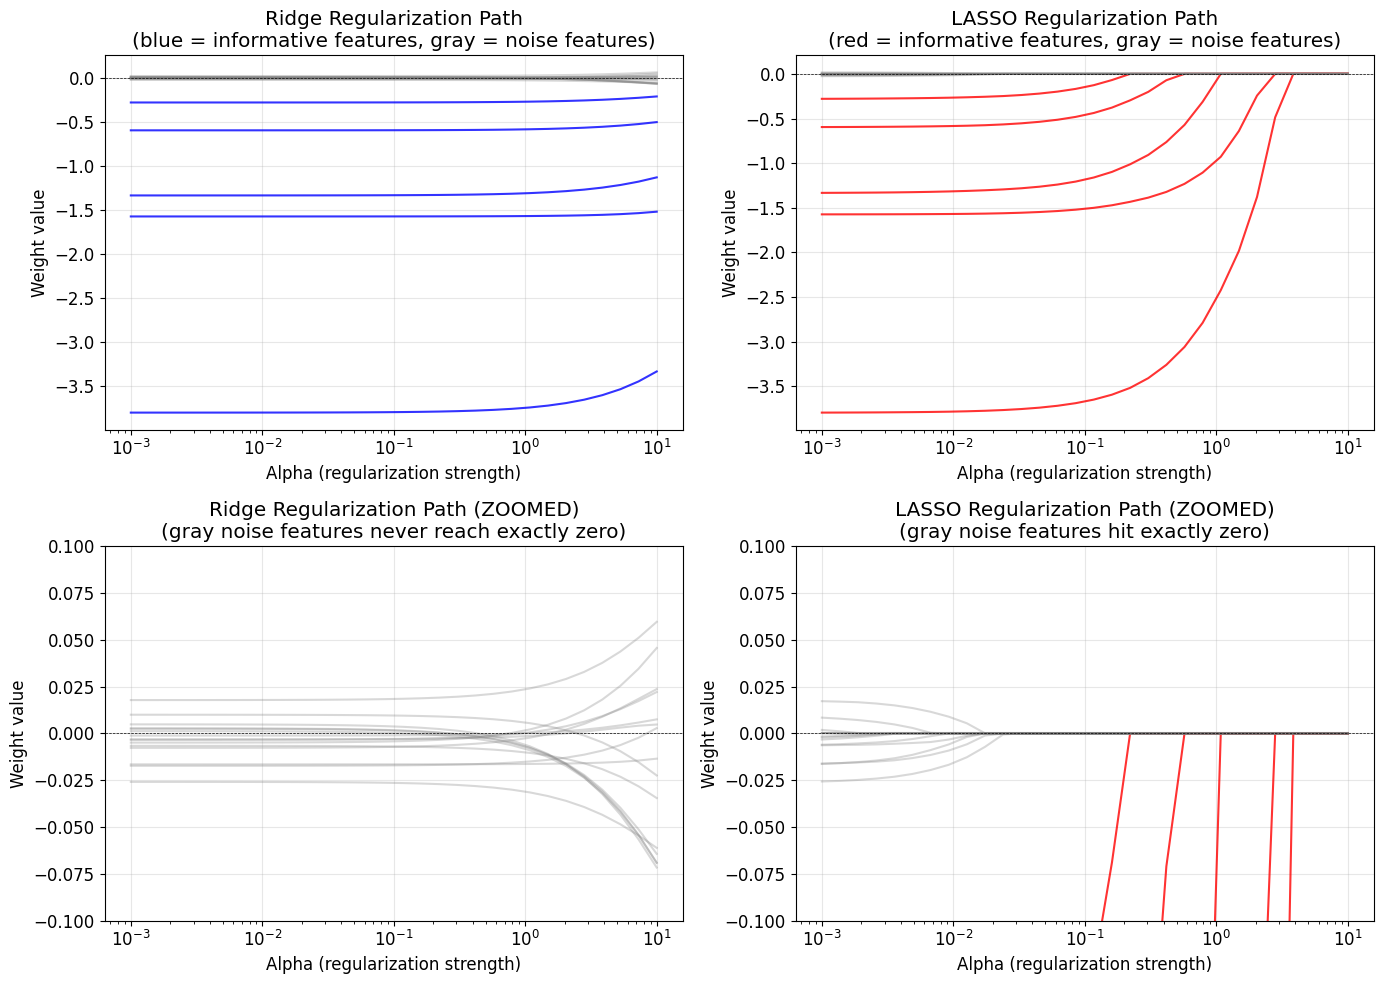

KEY OBSERVATION:
- Ridge: All weights shrink smoothly toward zero but never reach exactly zero
- LASSO: Weights hit exactly zero at different alpha values (sparse solutions)
- Noise features (gray) go to zero faster than informative features (colored)
- ZOOMED VIEW: Notice Ridge noise weights hover near zero but never hit it,
  while LASSO noise weights are exactly zero for most alpha values


In [23]:
# Compute and plot regularization paths
alphas = np.logspace(-3, 1, 30)
ridge_weights_path, lasso_weights_path = compute_regularization_paths(
    X_sparse, y_sparse, alphas, RidgeRegression, LassoRegression
)
plot_regularization_paths(alphas, ridge_weights_path, lasso_weights_path, n_informative=5)

### 6.6 When to Use Ridge vs LASSO

| Aspect | Ridge (L2) | LASSO (L1) |
|--------|------------|------------|
| **Solution** | Closed-form | Iterative (no closed-form) |
| **Sparsity** | No (all weights non-zero) | Yes (automatic feature selection) |
| **Correlated features** | Handles well | May arbitrarily select one |
| **Interpretability** | Harder (many features) | Easier (few non-zero features) |
| **Computation** | Faster | Slower |
| **Best when** | All features contribute | Only few features matter |

**Elastic Net** combines both: $\alpha_1 \|\mathbf{w}\|_1 + \alpha_2 \|\mathbf{w}\|_2^2$

---
## Section 7: Kernel Ridge Regression

### 7.1 Motivation: Non-Linear Regression

What if the relationship between features and target is non-linear? We could:
1. Manually create polynomial features (expensive for high-degree)
2. Use the **kernel trick** to implicitly work in a high-dimensional feature space

### 7.2 The Kernel Trick

Instead of explicitly computing features $\phi(\mathbf{x})$, we use a kernel function:

$$k(\mathbf{x}, \mathbf{x}') = \phi(\mathbf{x})^T \phi(\mathbf{x}')$$

### 7.3 Dual Form of Ridge Regression

The dual formulation of Ridge regression:

$$\boldsymbol{\alpha} = (\mathbf{K} + \lambda \mathbf{I})^{-1} \mathbf{y}$$

where $\mathbf{K}_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$ is the kernel matrix.

Prediction for new point $\mathbf{x}$:

$$\hat{y} = \sum_{i=1}^{n} \alpha_i k(\mathbf{x}, \mathbf{x}_i)$$

### 7.4 Common Kernel Functions

### Building Blocks for Kernel Ridge Regression

Before implementing the full `KernelRidgeRegression` class, let's build each piece step by step:

1. **Exercise 7.1** — Linear kernel function
2. **Exercise 7.2** — RBF kernel function (vectorized distance trick)
3. **Exercise 7.3** — Fit: compute kernel matrix and solve the dual system
4. **Exercise 7.4** — Predict: cross-kernel matrix and coefficients

Then in **Exercise 7.5** you'll combine them into the full class.

### Exercise 7.1: Linear Kernel

The linear kernel is the simplest kernel — just a dot product:

$$K(\mathbf{X}_1, \mathbf{X}_2) = \mathbf{X}_1 \mathbf{X}_2^T$$

Given $\mathbf{X}_1 \in \mathbb{R}^{n_1 \times p}$ and $\mathbf{X}_2 \in \mathbb{R}^{n_2 \times p}$, the result is an $n_1 \times n_2$ matrix where entry $(i, j)$ is the dot product of sample $i$ from $\mathbf{X}_1$ and sample $j$ from $\mathbf{X}_2$.

In [24]:
def linear_kernel(X1, X2):
    # SOLUTION
    return X1 @ X2.T


# --- Assertions ---
X_test_k = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
K_lin = linear_kernel(X_test_k, X_test_k)
assert K_lin.shape == (3, 3), f"Expected shape (3, 3), got {K_lin.shape}"
assert np.isclose(K_lin[0, 1], 0.0), "K(e1, e2) should be 0 for orthogonal unit vectors"
assert np.isclose(K_lin[0, 0], 1.0), "K(e1, e1) should be 1 for unit vectors"
assert np.isclose(K_lin[2, 2], 2.0), "K([1,1], [1,1]) should be 2"
print("Linear kernel matrix (3 test points):")
print(K_lin)
print("\nLinear kernel implemented correctly!")

Linear kernel matrix (3 test points):
[[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]

Linear kernel implemented correctly!


### Exercise 7.2: RBF (Gaussian) Kernel

The RBF kernel measures similarity that decays with distance:

$$K_{ij} = \exp\big(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\big)$$

**Key trick for vectorization** — expand the squared norm:

$$\|\mathbf{x}_i - \mathbf{x}_j\|^2 = \|\mathbf{x}_i\|^2 + \|\mathbf{x}_j\|^2 - 2\,\mathbf{x}_i^T \mathbf{x}_j$$

This lets you compute all pairwise distances using matrix operations — no loops!

Use `np.maximum(dist_sq, 0)` to clip any tiny negative values from floating-point arithmetic.

RBF kernel matrix (gamma=1.0):
[[1.     0.1353 0.3679]
 [0.1353 1.     0.3679]
 [0.3679 0.3679 1.    ]]

RBF kernel implemented correctly!


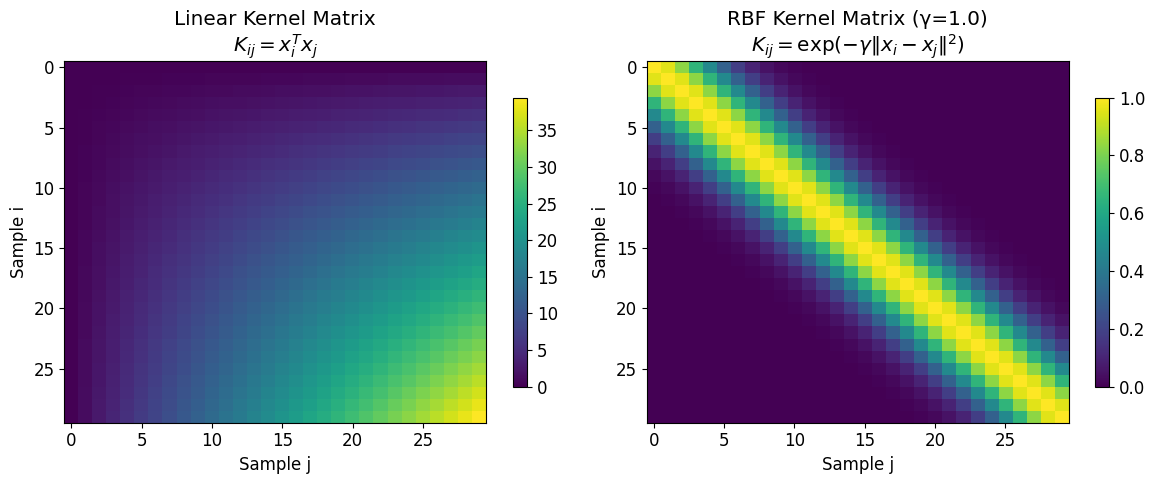

HOW TO READ THESE PLOTS:
Each cell (i, j) shows how similar sample i is to sample j.
Bright = high similarity, dark = low similarity.
Our training data is x = linspace(0, 2*pi), so sample index ≈ position.

LINEAR kernel (left): K_ij = x_i * x_j. The bottom-right corner is
brightest because both x_i and x_j are large there. The top-left is dark
because x-values near 0 give small dot products. This smooth gradient
means ALL training points contribute to every prediction with weights that
grow with x — the result is a single straight line, which cannot follow
a sine wave that goes up AND down.

RBF kernel (right): K_ij = exp(-γ ||x_i - x_j||²). The bright diagonal
band means each point is similar ONLY to its close neighbors — points
far apart (off the band) have near-zero similarity. Why does this help
with sin(x)? Because when predicting at some x, only nearby training
points get a vote. Near x=1 the sine is rising, near x=4 it's falling —
the RBF band ensures these regions don't interf

In [25]:
def rbf_kernel(X1, X2, gamma=1.0):
    """RBF kernel: K_ij = exp(-gamma * ||x_i - x_j||^2), vectorized."""
    # SOLUTION
    X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
    X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
    dist_sq = X1_sq + X2_sq - 2 * X1 @ X2.T
    dist_sq = np.maximum(dist_sq, 0)
    return np.exp(-gamma * dist_sq)


# --- Assertions ---
K_rbf = rbf_kernel(X_test_k, X_test_k, gamma=1.0)
assert K_rbf.shape == (3, 3), f"Expected shape (3, 3), got {K_rbf.shape}"
# Self-similarity: diagonal should be 1
assert np.allclose(np.diag(K_rbf), 1.0), "RBF self-similarity should be 1"
# All values in [0, 1]
assert np.all(K_rbf >= 0) and np.all(K_rbf <= 1.0), "RBF values should be in [0, 1]"
# Symmetry
assert np.allclose(K_rbf, K_rbf.T), "Kernel matrix should be symmetric"
# Higher gamma = faster decay = smaller off-diagonal
K_rbf_high = rbf_kernel(X_test_k, X_test_k, gamma=10.0)
assert K_rbf_high[0, 1] < K_rbf[0, 1], "Higher gamma should give smaller off-diagonal values"
print("RBF kernel matrix (gamma=1.0):")
print(np.round(K_rbf, 4))
print("\nRBF kernel implemented correctly!")

# Visualize both kernel matrices
X_train_sin, y_train_sin, _, _ = generate_sinusoidal_data(n_train=30)
plot_kernel_matrices(X_train_sin, linear_kernel, rbf_kernel, gamma=1.0)

### Exercise 7.3: Fit — Solve the Dual System

Given training data $\mathbf{X}$, targets $\mathbf{y}$, a kernel function, and regularization $\alpha$:

1. Compute the kernel matrix: $\mathbf{K} = k(\mathbf{X}, \mathbf{X})$
2. Solve the regularized system: $(\mathbf{K} + \alpha \mathbf{I})\boldsymbol{\beta} = \mathbf{y}$

Use `np.linalg.solve` (not `np.linalg.inv`) — it is more numerically stable.

In [26]:
def kernel_ridge_fit(X, y, kernel_fn, alpha=1.0, **kernel_params):
    """Fit kernel ridge regression. Returns coefficients beta."""
    # SOLUTION
    K = kernel_fn(X, X, **kernel_params)
    n = K.shape[0]
    beta = np.linalg.solve(K + alpha * np.eye(n), y)
    return beta


# --- Assertions ---
X_train_sin, y_train_sin, _, _ = generate_sinusoidal_data(n_train=30)
beta_rbf = kernel_ridge_fit(X_train_sin, y_train_sin, rbf_kernel, alpha=0.1, gamma=1.0)
assert beta_rbf.shape == (30,), f"Expected shape (30,), got {beta_rbf.shape}"
# Verify the system is solved: (K + alpha*I) @ beta ≈ y
K_check = rbf_kernel(X_train_sin, X_train_sin, gamma=1.0)
residual = np.linalg.norm((K_check + 0.1 * np.eye(30)) @ beta_rbf - y_train_sin)
assert residual < 1e-8, f"System residual too large: {residual:.2e}"
print(f"Coefficient vector shape: {beta_rbf.shape}")
print(f"System residual: {residual:.2e} (should be < 1e-8)")
print("\nFit implemented correctly!")

Coefficient vector shape: (30,)
System residual: 9.53e-16 (should be < 1e-8)

Fit implemented correctly!


### Exercise 7.4: Predict — Cross-Kernel and Coefficients

To predict for new points $\mathbf{X}_{\text{new}}$:

1. Compute the cross-kernel matrix: $\mathbf{K}_{\text{new}} = k(\mathbf{X}_{\text{new}}, \mathbf{X}_{\text{train}})$
2. Multiply by coefficients: $\hat{\mathbf{y}} = \mathbf{K}_{\text{new}} \boldsymbol{\beta}$

Linear kernel MSE: 0.4228
RBF kernel MSE:    0.0027

RBF beats linear on non-linear data — as expected!


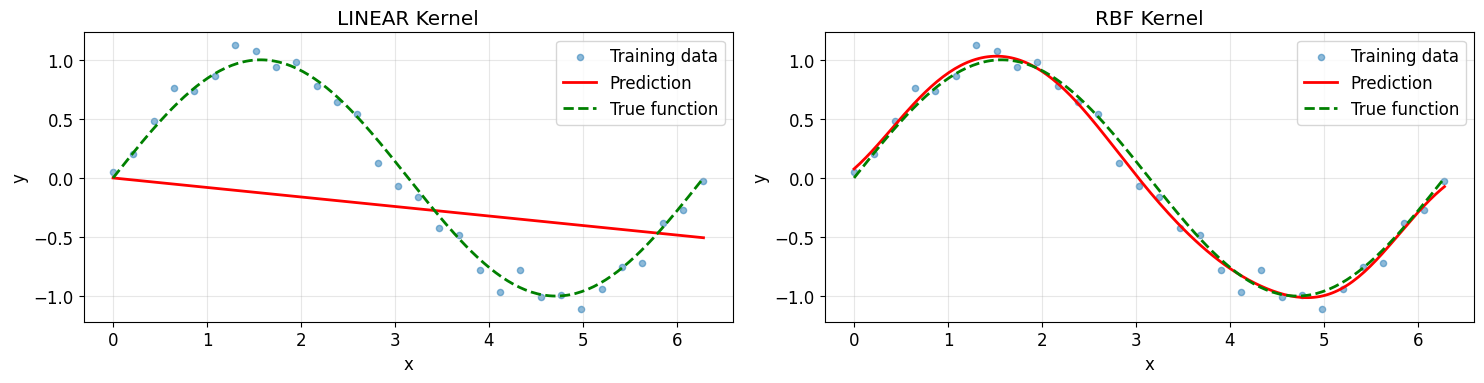

Notice how RBF kernel captures the non-linear sinusoidal pattern,
while linear kernel can only fit a straight line!


In [27]:
def kernel_ridge_predict(X_new, X_train, coeffs, kernel_fn, **kernel_params):
    """Predict using fitted kernel ridge regression."""
    # SOLUTION
    K_new = kernel_fn(X_new, X_train, **kernel_params)
    return K_new @ coeffs


# --- Assertions ---
X_train_sin, y_train_sin, X_test_sin, y_true_sin = generate_sinusoidal_data(n_train=30)

# Fit + predict with linear kernel
beta_lin = kernel_ridge_fit(X_train_sin, y_train_sin, linear_kernel, alpha=0.1)
y_pred_lin = kernel_ridge_predict(X_test_sin, X_train_sin, beta_lin, linear_kernel)
assert y_pred_lin.shape == (200,), f"Expected shape (200,), got {y_pred_lin.shape}"
mse_lin = np.mean((y_pred_lin - y_true_sin) ** 2)

# Fit + predict with RBF kernel
beta_rbf = kernel_ridge_fit(X_train_sin, y_train_sin, rbf_kernel, alpha=0.1, gamma=1.0)
y_pred_rbf = kernel_ridge_predict(X_test_sin, X_train_sin, beta_rbf, rbf_kernel, gamma=1.0)
mse_rbf = np.mean((y_pred_rbf - y_true_sin) ** 2)

print(f"Linear kernel MSE: {mse_lin:.4f}")
print(f"RBF kernel MSE:    {mse_rbf:.4f}")
assert mse_rbf < mse_lin, "RBF should outperform linear on sinusoidal data"
print("\nRBF beats linear on non-linear data — as expected!")

# Visualize
plot_kernel_comparison(X_train_sin, y_train_sin, X_test_sin, y_true_sin, [y_pred_lin, y_pred_rbf], ["linear", "rbf"])

### Exercise 7.5: Combine the Building Blocks into a KernelRidgeRegression Class

In [28]:
class KernelRidgeRegression:
    """
    Kernel Ridge Regression.

    Uses the dual formulation to enable non-linear regression via kernels.

    The key idea:
    - Compute kernel matrix K where K_ij = k(x_i, x_j)
    - Solve (K + alpha * I) @ coeffs = y for coefficients
    - Predict: y_new = K(X_new, X_train) @ coeffs

    Parameters
    ----------
    alpha : float
        Regularization strength
    kernel : str
        'linear' or 'rbf'
    gamma : float
        Kernel coefficient for 'rbf': k(x, x') = exp(-gamma * ||x - x'||^2)
    """

    def __init__(self, alpha: float = 1.0, kernel: str = "rbf", gamma: float = 1.0):
        self.alpha = alpha
        self.kernel = kernel
        self.gamma = gamma

    def _compute_kernel(self, X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
        """Compute kernel matrix between X1 and X2 (vectorized)."""
        if self.kernel == "linear":
            return X1 @ X2.T
        elif self.kernel == "rbf":
            # ||x_i - x_j||^2 = ||x_i||^2 + ||x_j||^2 - 2 * x_i^T x_j
            X1_sq = np.sum(X1**2, axis=1, keepdims=True)
            X2_sq = np.sum(X2**2, axis=1, keepdims=True)
            dist_sq = X1_sq + X2_sq.T - 2 * X1 @ X2.T
            return np.exp(-self.gamma * np.maximum(dist_sq, 0))
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")

    def fit(self, X: np.ndarray, y: np.ndarray) -> "KernelRidgeRegression":
        """
        Fit the kernel ridge regression model.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Training data
        y : np.ndarray of shape (n_samples,)
            Target values

        Returns
        -------
        self : KernelRidgeRegression
            Fitted model
        """
        y = np.asarray(y).ravel()
        n_samples = X.shape[0]

        # SOLUTION
        # Store training data (needed for prediction)
        self._X_train = X.copy()

        # Compute kernel matrix and solve for coefficients
        K = self._compute_kernel(X, X)
        self._coeffs = np.linalg.solve(K + self.alpha * np.eye(n_samples), y)

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict using the kernel ridge regression model.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Samples to predict

        Returns
        -------
        y_pred : np.ndarray of shape (n_samples,)
            Predicted values
        """
        # SOLUTION
        K = self._compute_kernel(X, self._X_train)
        return K @ self._coeffs

### Run tests for KernelRidgeRegression

Run this cell after implementing your `KernelRidgeRegression` class:

Testing KernelRidgeRegression...


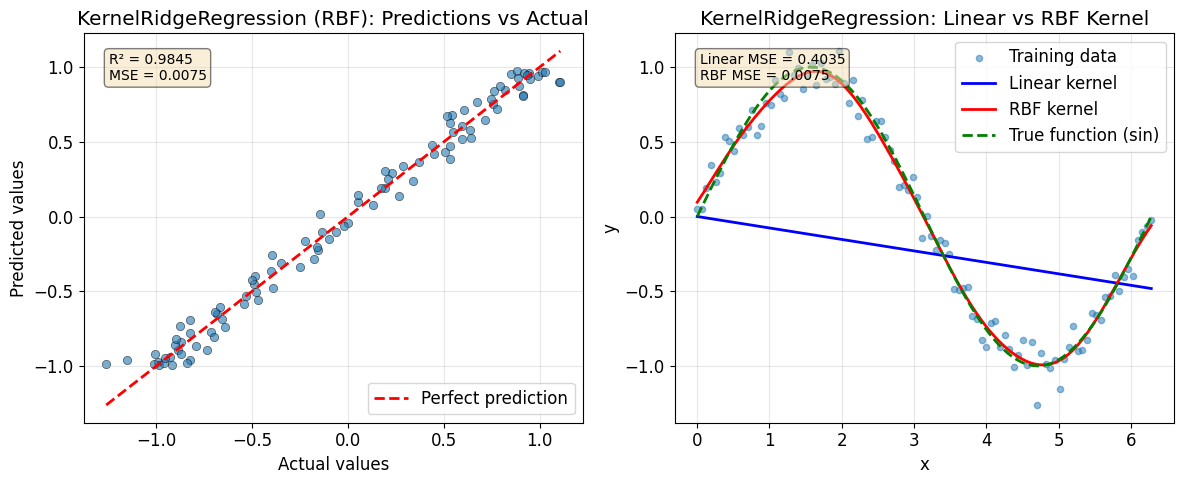

  ✓ fit_returns_self
  ✓ predict_shape
  ✓ rbf_fit_quality
  ✓ linear_kernel_fit
  ✓ rbf_vs_linear
  ✓ generalization

KernelRidgeRegression: 6/6 tests passed
🎉 All tests passed!


{'passed': 6,
 'failed': 0,
 'results': [('fit_returns_self', True, 'fit() should return self'),
  ('predict_shape', True, 'Expected shape (100,), got (100,)'),
  ('rbf_fit_quality', np.True_, 'RBF MSE (0.0057) should be < 0.1'),
  ('linear_kernel_fit',
   np.True_,
   'Linear kernel MSE (0.0076) should be < 0.1'),
  ('rbf_vs_linear',
   np.True_,
   'RBF MSE (0.0075) should be < linear MSE (0.4035)'),
  ('generalization', np.True_, 'Should predict reasonably on new data')]}

In [29]:
# Test your KernelRidgeRegression implementation
run_single_test(KernelRidgeRegression, check_kernel_ridge_regression)

---
## Section 8: Logistic Regression -- From Regression to Classification

So far, all our models predict **continuous** values. Now we switch to **binary classification**: given features $\mathbf{x}$, predict a label $y \in \{0, 1\}$.

Logistic regression is built from four building blocks. We will implement each one individually, then combine them into a full `LogisticRegression` class.

### 8.1 The Sigmoid Function

We need a function that maps any real number to the range $[0, 1]$ (a probability):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Properties:
- $\sigma(0) = 0.5$
- $\sigma(z) \to 1$ as $z \to +\infty$
- $\sigma(z) \to 0$ as $z \to -\infty$
- $\sigma'(z) = \sigma(z)(1 - \sigma(z))$

### Exercise 8.1: Implement the Sigmoid Function

Implement the sigmoid function as a standalone function. Use `np.clip(z, -500, 500)` before computing `exp` to avoid numerical overflow.

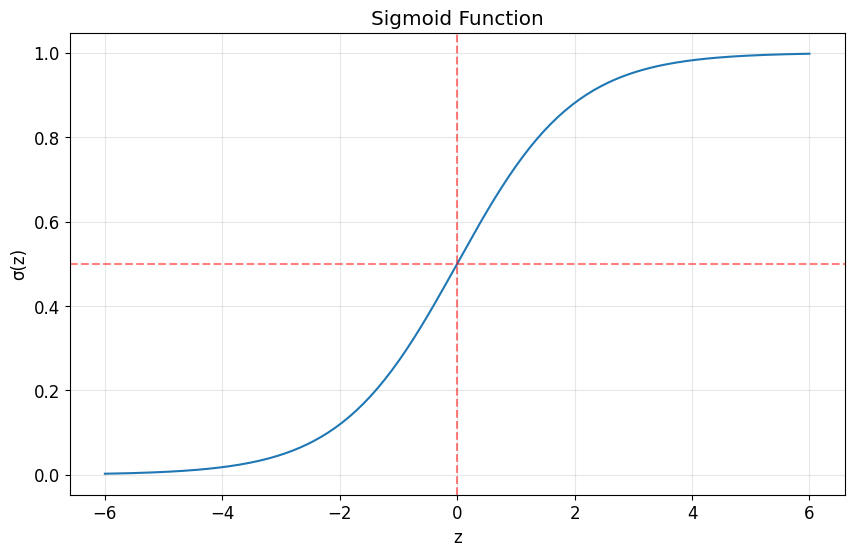

Sigmoid implemented correctly!


In [30]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """Compute the sigmoid: sigma(z) = 1 / (1 + exp(-z))."""
    # SOLUTION
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


# Quick check
assert np.isclose(sigmoid(0.0), 0.5), "sigmoid(0) should be 0.5"
assert sigmoid(100.0) > 0.99, "sigmoid(large positive) should be close to 1"
assert sigmoid(-100.0) < 0.01, "sigmoid(large negative) should be close to 0"

# Plot the sigmoid curve
plot_sigmoid_curve(sigmoid)

Sigmoid values at key points:
  sigmoid( 500) = 1.0
  sigmoid(-500) = 7.124576406741285e-218
  sigmoid(  20) = 0.999999997938846
  sigmoid( -20) = 2.061153618190204e-09

By z = +/-20, sigmoid is already within 1e-9 of its limit.
Clipping at +/-500 changes nothing about the output --
it only prevents np.exp from overflowing on extreme inputs.


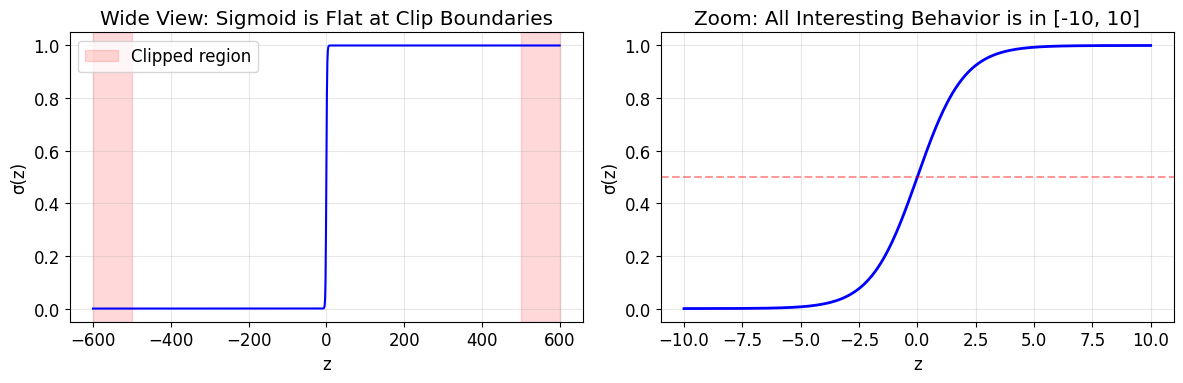

In [31]:
# Why is np.clip(z, -500, 500) safe?
# Let's see how close sigmoid already is to 0 or 1 at the clip boundaries.
plot_sigmoid_clipping_demo(sigmoid)

### 8.2 The Model: From Features to Probabilities

The logistic regression model computes a probability in two steps:
1. **Linear combination**: $z = \mathbf{X} \mathbf{w} + b$ (just like linear regression, plus a bias)
2. **Sigmoid squash**: $p = \sigma(z)$ — turns the real-valued score into a probability

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

### Exercise 8.2: Compute Predicted Probabilities

Using your `sigmoid` from above, compute class-1 probabilities for the given data.

In [32]:
# Example data (4 samples, 2 features)
X_ex = np.array([[1.0, 2.0], [-1.0, 0.5], [0.5, -1.0], [2.0, 1.0]])
w_ex = np.array([0.8, -0.5])
b_ex = 0.1

# SOLUTION
p = sigmoid(X_ex @ w_ex + b_ex)


# Quick check
assert p.shape == (4,), f"Expected shape (4,), got {p.shape}"
assert np.all((p >= 0) & (p <= 1)), "All probabilities must be in [0, 1]"
print("Predicted probabilities:", np.round(p, 4))
print("Predicted labels (threshold 0.5):", (p >= 0.5).astype(int))

Predicted probabilities: [0.475  0.2789 0.7311 0.7685]
Predicted labels (threshold 0.5): [0 0 1 1]


### 8.3 The Loss: Binary Cross-Entropy (Log Loss)

We need a loss function that measures how wrong our predicted probabilities are. For binary classification the natural choice is **log loss** (binary cross-entropy):

$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n}\sum_{i=1}^{n} \Big[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \Big]$$

Intuition:
- When $y_i = 1$: we penalize $-\log(p_i)$, so the loss is low only when $p_i \approx 1$
- When $y_i = 0$: we penalize $-\log(1 - p_i)$, so the loss is low only when $p_i \approx 0$

### Exercise 8.3: Compute the Log Loss

Implement the log loss function. Add a small epsilon (`1e-15`) inside the `log` to prevent `log(0)`.

In [33]:
def log_loss(y_true: np.ndarray, p: np.ndarray) -> float:
    """Compute binary cross-entropy loss."""
    eps = 1e-15
    # SOLUTION
    return -np.mean(y_true * np.log(p + eps) + (1 - y_true) * np.log(1 - p + eps))


# Quick check with known values
y_check = np.array([1, 0, 1, 0])
p_perfect = np.array([0.99, 0.01, 0.99, 0.01])
p_random = np.array([0.5, 0.5, 0.5, 0.5])
p_bad = np.array([0.01, 0.99, 0.01, 0.99])

loss_perfect = log_loss(y_check, p_perfect)
loss_random = log_loss(y_check, p_random)
loss_bad = log_loss(y_check, p_bad)

print(f"Loss (near-perfect predictions): {loss_perfect:.4f}")
print(f"Loss (random predictions):       {loss_random:.4f}")
print(f"Loss (terrible predictions):     {loss_bad:.4f}")
assert loss_perfect < loss_random < loss_bad, "Losses should increase as predictions get worse"
print("\nLog loss implemented correctly!")

Loss (near-perfect predictions): 0.0101
Loss (random predictions):       0.6931
Loss (terrible predictions):     4.6052

Log loss implemented correctly!


### 8.4 The Gradient: One Step of Gradient Descent

To minimize the log loss, we take the gradient with respect to $\mathbf{w}$ and $b$:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{n} \mathbf{X}^T (\mathbf{p} - \mathbf{y}), \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} (p_i - y_i)$$

One gradient descent update:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{w}}, \qquad b \leftarrow b - \eta \frac{\partial \mathcal{L}}{\partial b}$$

### Exercise 8.4: Implement One Gradient Descent Step

Given current weights, bias, data, and labels, compute the gradients and return updated weights and bias.

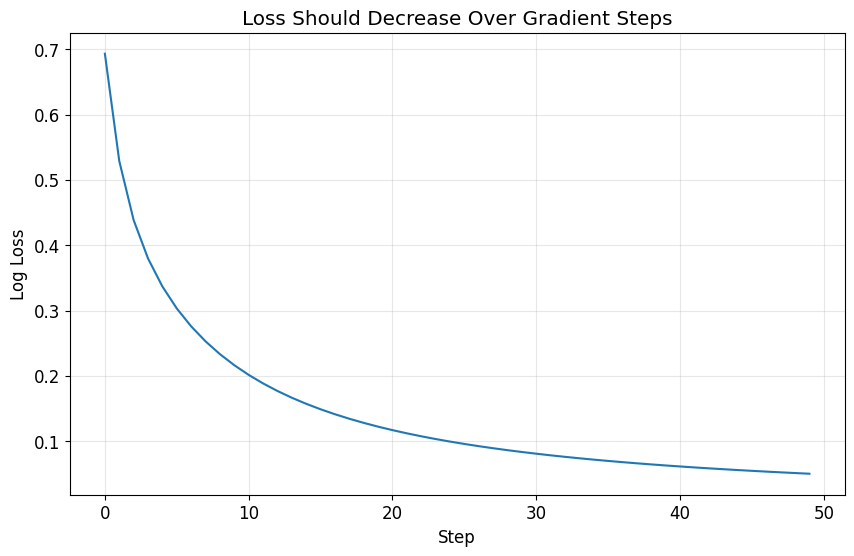

Loss decreased from 0.6931 to 0.0501
Gradient step implemented correctly!


In [34]:
def gradient_step(X, y, w, b, lr=0.1):
    """Perform one gradient descent step. Return (new_w, new_b, loss)."""
    n = X.shape[0]
    # SOLUTION
    p = sigmoid(X @ w + b)
    dw = (1 / n) * X.T @ (p - y)
    db = (1 / n) * np.sum(p - y)
    w_new = w - lr * dw
    b_new = b - lr * db
    loss = log_loss(y, p)
    return w_new, b_new, loss


# Quick check: run a few steps on example data and verify loss decreases
X_ex = np.array([[1.0, 2.0], [-1.0, 0.5], [0.5, -1.0], [2.0, 1.0]])
y_ex = np.array([1, 0, 0, 1])
w_cur = np.zeros(2)
b_cur = 0.0

losses = []
for step in range(50):
    w_cur, b_cur, loss = gradient_step(X_ex, y_ex, w_cur, b_cur, lr=0.5)
    losses.append(loss)

assert losses[-1] < losses[0], "Loss should decrease after gradient steps"
plot_gradient_descent_loss(losses)

### Exercise 8.5: Combine the Building Blocks into a LogisticRegression Class

You've now implemented each piece in isolation:
- **Sigmoid** (8.1) — squash scores to probabilities
- **Model prediction** (8.2) — compute $p = \sigma(\mathbf{X}\mathbf{w} + b)$
- **Log loss** (8.3) — measure prediction quality
- **Gradient step** (8.4) — update weights to reduce the loss

Now put them all together inside a single class. The `fit` method runs gradient descent in a loop, and the `predict`/`predict_proba` methods use the learned weights.

In [35]:
class LogisticRegression:
    """
    Logistic Regression for binary classification.

    Uses gradient descent to minimize binary cross-entropy (log loss).

    Parameters
    ----------
    lr : float, default=0.1
        Learning rate for gradient descent.
    max_iter : int, default=1000
        Maximum number of gradient descent iterations.
    tol : float, default=1e-6
        Tolerance for convergence (based on loss change).
    """

    def __init__(self, lr: float = 0.1, max_iter: int = 1000, tol: float = 1e-6):
        self.lr = lr
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.bias = None
        self.n_iter_ = 0

    def sigmoid(self, z: np.ndarray) -> np.ndarray:
        """
        Sigmoid activation function: sigma(z) = 1 / (1 + exp(-z))

        Parameters
        ----------
        z : np.ndarray
            Input values

        Returns
        -------
        np.ndarray
            Sigmoid of z, same shape as input
        """
        # SOLUTION
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegression":
        """
        Fit the logistic regression model using gradient descent.

        For each iteration:
        1. Compute predictions: p = sigmoid(X @ w + b)
        2. Compute gradients:
           - dw = (1/n) * X^T @ (p - y)
           - db = (1/n) * sum(p - y)
        3. Update weights: w -= lr * dw, b -= lr * db

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Training data
        y : np.ndarray of shape (n_samples,)
            Binary target values (0 or 1)

        Returns
        -------
        self : LogisticRegression
            Fitted model
        """
        y = np.asarray(y).ravel()
        n_samples, n_features = X.shape

        # Initialize weights and bias to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        # SOLUTION: Gradient descent
        prev_loss = float("inf")
        for iteration in range(self.max_iter):
            p = self.sigmoid(X @ self.weights + self.bias)

            # Gradients
            dw = (1 / n_samples) * X.T @ (p - y)
            db = (1 / n_samples) * np.sum(p - y)

            # Update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Convergence check
            eps = 1e-15
            loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
            if abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

        self.n_iter_ = iteration + 1

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Predict class probabilities.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Samples to predict

        Returns
        -------
        proba : np.ndarray of shape (n_samples,)
            Probability of class 1 for each sample
        """
        # SOLUTION
        return self.sigmoid(X @ self.weights + self.bias)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict class labels (0 or 1).

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Samples to predict

        Returns
        -------
        labels : np.ndarray of shape (n_samples,)
            Predicted class labels (0 or 1)
        """
        # SOLUTION
        return (self.predict_proba(X) >= 0.5).astype(int)

### Run tests for LogisticRegression

Run this cell after implementing your `LogisticRegression` class:

Testing LogisticRegression...
Training accuracy: 99.50%


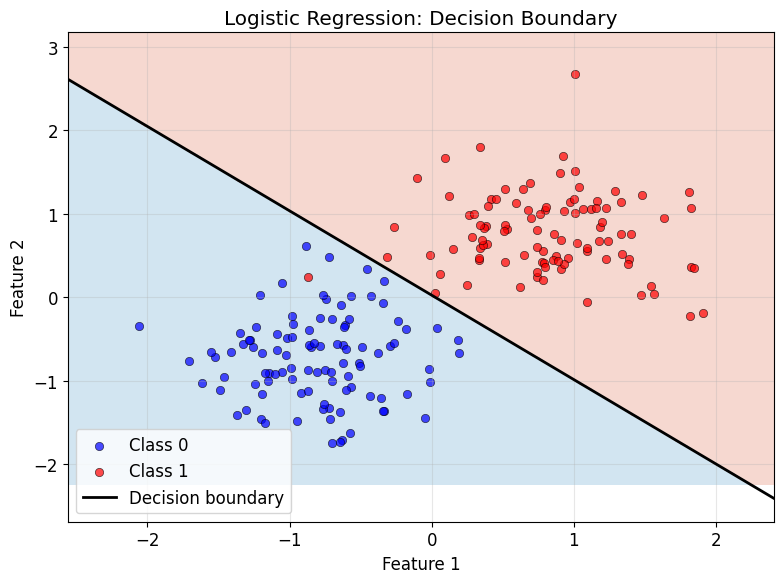

  ✓ fit_returns_self
  ✓ weights_shape
  ✓ predict_proba_valid
  ✓ predict_labels
  ✓ accuracy
  ✓ sigmoid

LogisticRegression: 6/6 tests passed
🎉 All tests passed!


{'passed': 6,
 'failed': 0,
 'results': [('fit_returns_self', True, 'fit() should return self'),
  ('weights_shape', True, 'Expected shape (2,), got (2,)'),
  ('predict_proba_valid',
   np.True_,
   'predict_proba should return values in [0, 1]'),
  ('predict_labels', True, 'predict should return 0/1 integer labels'),
  ('accuracy', np.True_, 'Training accuracy (99.50%) should be > 85%'),
  ('sigmoid',
   np.True_,
   'sigmoid(0)=0.5, sigmoid(large)~1, sigmoid(-large)~0')]}

In [36]:
# Test your LogisticRegression implementation
run_single_test(LogisticRegression, check_logistic_regression)

### 8.6 Visualizing the Decision Boundary

For 2D features, the decision boundary is the line where $P(y=1) = 0.5$, i.e., where $\mathbf{w}^T \mathbf{x} + b = 0$:

$$x_2 = -\frac{w_1 x_1 + b}{w_2}$$

Training accuracy: 99.50%


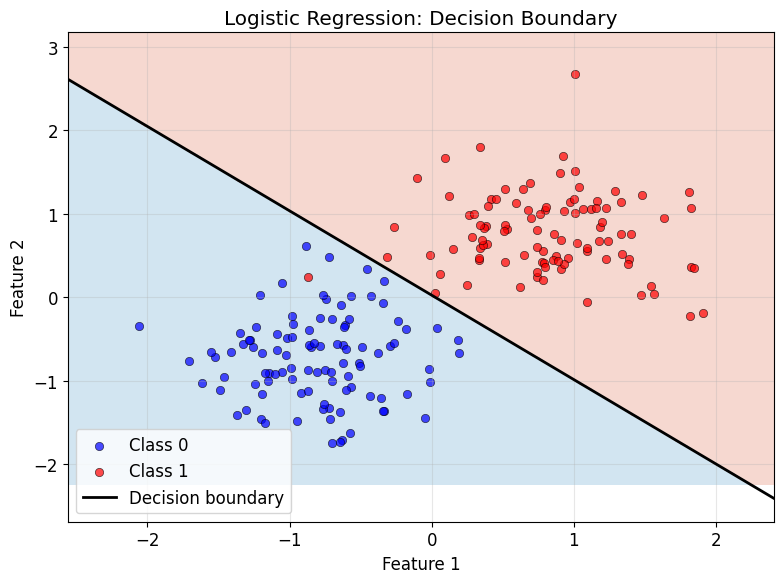

In [37]:
# Generate 2D binary classification data and visualize the decision boundary
X_clf, y_clf = generate_classification_data()
model_clf = LogisticRegression(lr=0.1, max_iter=1000).fit(X_clf, y_clf)

# Plot decision boundary
plot_decision_boundary(X_clf, y_clf, model_clf)

### 8.7 Key Takeaways

- **Sigmoid function** maps any real number to a probability in $[0, 1]$
- **Log loss** (binary cross-entropy) is the natural loss function for binary classification
- **No closed-form solution** -- we must use iterative gradient descent
- **Decision boundary** is linear in the feature space: $\mathbf{w}^T \mathbf{x} + b = 0$
- Logistic regression is the classification analogue of linear regression

---
## Section 9: Summary

### Key Takeaways

1. **Linear Regression (OLS)** has a closed-form solution: $\mathbf{w}^* = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$

2. **Numerical Instability**: When features are correlated, $\mathbf{X}^T\mathbf{X}$ becomes ill-conditioned:
   - High condition number = sensitive to perturbations
   - Tiny changes in data cause huge changes in weights
   - Solutions can be wildly wrong

3. **Ridge Regression (L2)** fixes numerical instability:
   - $\mathbf{w}^* = (\mathbf{X}^T\mathbf{X} + \alpha\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$
   - Adding $\alpha\mathbf{I}$ shifts eigenvalues, reducing condition number
   - All weights remain non-zero (no feature selection)

4. **LASSO Regression (L1)** provides sparse solutions:
   - Minimizes $\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \alpha \|\mathbf{w}\|_1$
   - No closed-form solution (use coordinate descent)
   - Weights can be exactly zero (automatic feature selection)

5. **Ridge vs LASSO**:
   - Ridge: Use when all features matter, handles correlated features well
   - LASSO: Use when you expect only few features matter, provides interpretability

6. **Kernel Ridge Regression** extends to non-linear relationships:
   - Dual form: $\boldsymbol{\alpha} = (\mathbf{K} + \lambda\mathbf{I})^{-1}\mathbf{y}$
   - Kernel trick avoids explicit feature computation
   - Common kernels: linear, polynomial, RBF

7. **Logistic Regression** bridges regression and classification:
   - Sigmoid function maps linear outputs to probabilities
   - Binary cross-entropy (log loss) is the natural loss function
   - No closed-form solution; uses gradient descent
   - Decision boundary is linear in the feature space

---
## Section 10: Test Your Implementations

Run the cell below to test your implementations against the test harness.


Testing LinearRegression


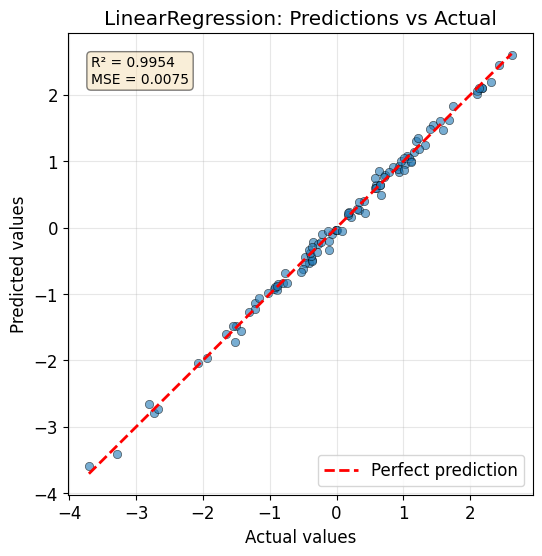

  ✓ fit_returns_self: PASSED
  ✓ weights_shape: PASSED
  ✓ predict_shape: PASSED
  ✓ correctness: PASSED
  ✓ perfect_fit: PASSED

  LinearRegression: 5/5 tests passed

Testing RidgeRegression


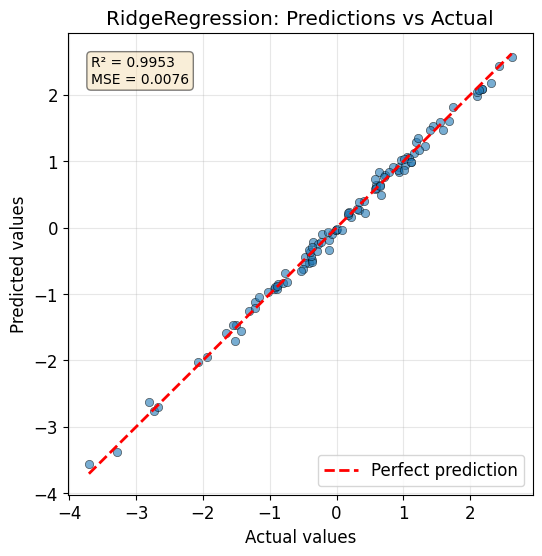

  ✓ fit_returns_self: PASSED
  ✓ weights_shape: PASSED
  ✓ shrinks_weights: PASSED
  ✓ numerical_stability: PASSED
  ✓ condition_improvement: PASSED

  RidgeRegression: 5/5 tests passed

Testing LassoRegression


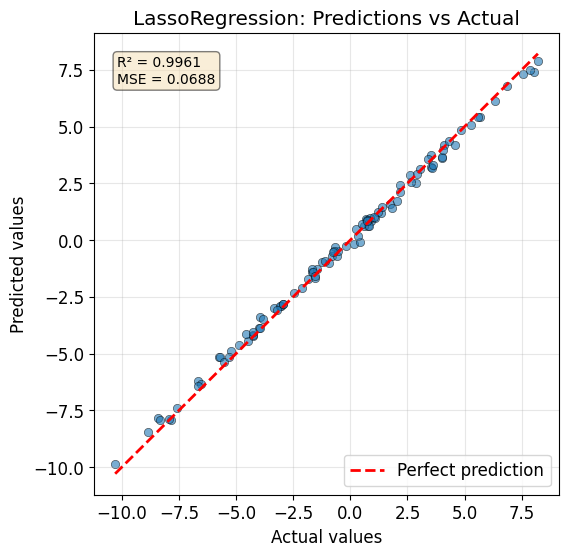

  ✓ fit_returns_self: PASSED
  ✓ weights_shape: PASSED
  ✓ sparsity: PASSED
  ✓ more_sparsity: PASSED
  ✓ feature_selection: PASSED

  LassoRegression: 5/5 tests passed

Testing KernelRidgeRegression


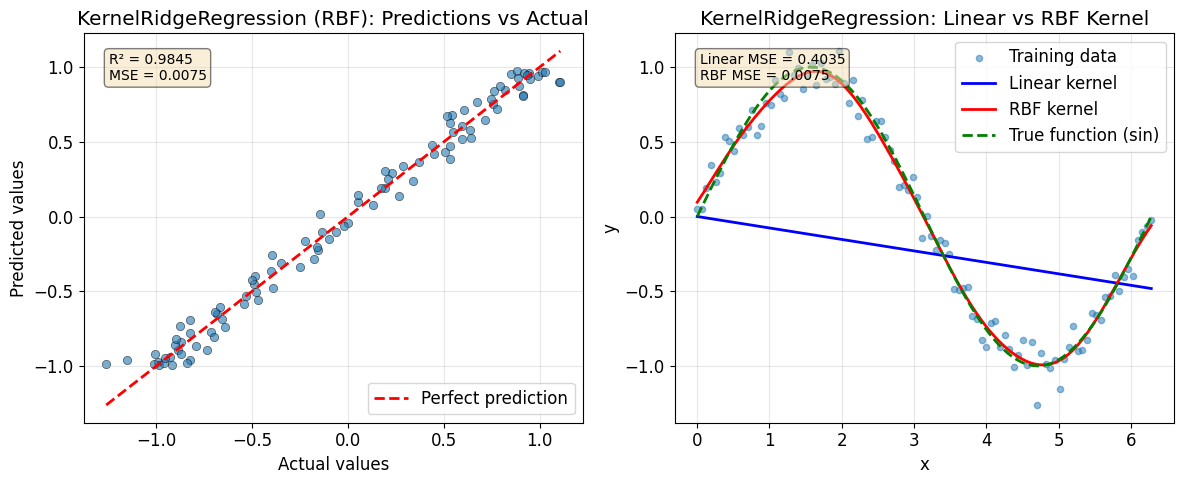

  ✓ fit_returns_self: PASSED
  ✓ predict_shape: PASSED
  ✓ rbf_fit_quality: PASSED
  ✓ linear_kernel_fit: PASSED
  ✓ rbf_vs_linear: PASSED
  ✓ generalization: PASSED

  KernelRidgeRegression: 6/6 tests passed

Testing LogisticRegression
Training accuracy: 99.50%


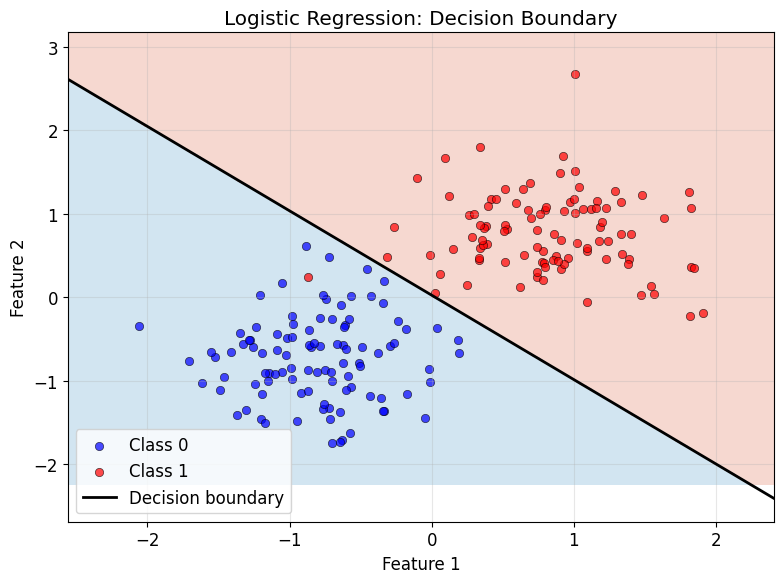

  ✓ fit_returns_self: PASSED
  ✓ weights_shape: PASSED
  ✓ predict_proba_valid: PASSED
  ✓ predict_labels: PASSED
  ✓ accuracy: PASSED
  ✓ sigmoid: PASSED

  LogisticRegression: 6/6 tests passed

TOTAL: 27 passed, 0 failed

Congratulations! All tests passed!
Your implementations are complete and correct.


In [38]:
# Final verification: run all tests at once
# (You should have already passed individual tests after each implementation)
results = run_tests(
    LinearRegressionClass=LinearRegression,
    RidgeRegressionClass=RidgeRegression,
    LassoRegressionClass=LassoRegression,
    KernelRidgeRegressionClass=KernelRidgeRegression,
    LogisticRegressionClass=LogisticRegression,
    verbose=True,
)

# Final summary
print("\n" + "=" * 60)
if results["failed"] == 0:
    print("Congratulations! All tests passed!")
    print("Your implementations are complete and correct.")
else:
    print(f"{results['failed']} tests failed. Review the implementations above.")